# Statewide races

Note: 'current' results are currently pointing to 2022 results, so as to be able to verify the model is working.

In [90]:
import pandas as pd

regions_nonmetro = pd.read_csv('./regions/regions_nonmetro.csv', index_col='County')
regions_nonmetro

,Region,Subregion
County,,
Banks,East,Outer East Georgia
Barrow,East,Metro Athens
Clarke,East,Metro Athens
Elbert,East,Outer East Georgia
Franklin,East,Outer East Georgia
...,...,...
Heard,West,Newnan-LaGrange
Meriwether,West,Newnan-LaGrange
Paulding,West,Carrollton-Paulding


Text(0.5, 1.0, 'Non-Metro Regions')

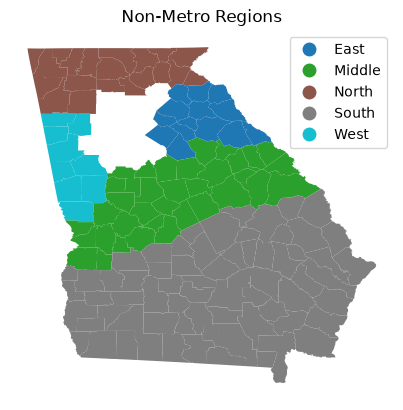

In [91]:
import utils

counties = utils.import_county_map()
counties['Region'] = regions_nonmetro['Region']
regions = counties['Region'].unique()
ax = counties.plot(column='Region', legend=True)
ax.set_axis_off()
ax.set_title('Non-Metro Regions')

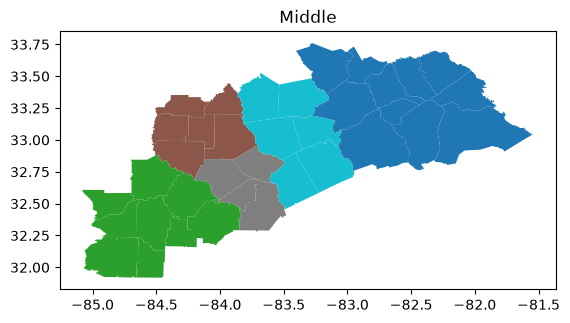

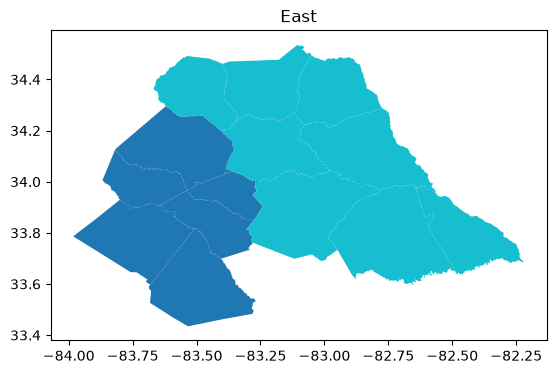

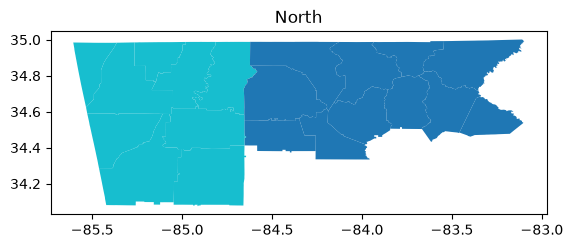

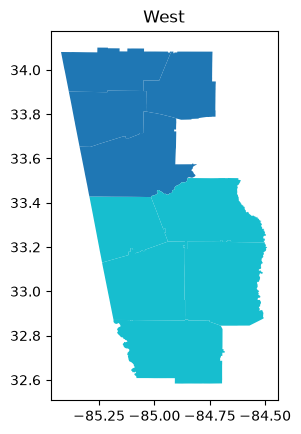

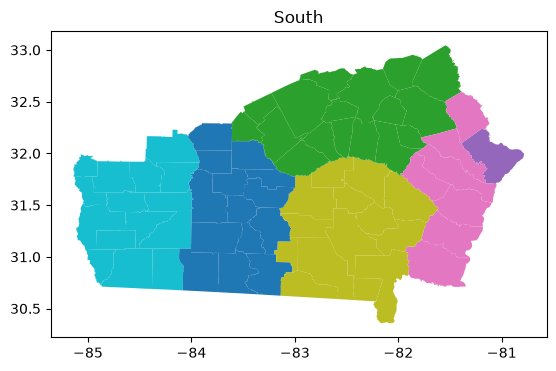

In [92]:
counties['Subregion'] = regions_nonmetro['Subregion']

for region in regions:
    if str(region) == 'nan':
        continue
    counties_f = counties[counties['Region'] == region]
    ax = counties_f.plot(column='Subregion')#, legend=True)
    ax.set_title(region)


In [93]:
def import_historical(year, office, metro=False):
    ext = '_metro' if metro else ''
    unit = ['County', 'Precinct'] if metro else ['County']
    data = pd.read_csv(f'./data/{year}_{office}{ext}.csv', index_col=[*unit, 'Vote Method'])
    return data

In [94]:
def display_single_results(df):
    res = df.sum()
    res = pd.DataFrame(res, columns=['Votes'])
    res = res.sort_values(by='Votes', ascending=False)
    res['Share'] = (res['Votes'] / res['Votes'].sum() * 100)
    return res

# Metro GIS

In [95]:
import pandas as pd
import geopandas

metro_prec_data = geopandas.read_file('./regions/regions_metro.json')
metro_prec_data[metro_prec_data['Election'].isin(['2018', '2022', '*'])]
metro_prec_data = metro_prec_data.rename(columns={'index': 'Precinct'})

# Sanitizing for 2022
def sanitize_gwinnett_2022(x):
    return ' '.join(x.split(' ')[1:])
metro_prec_data.loc[metro_prec_data['County'] == 'Gwinnett', 'Precinct'] = \
    metro_prec_data.loc[metro_prec_data['County'] == 'Gwinnett', 'Precinct'].apply(sanitize_gwinnett_2022)

def sanitize_hall_2022(x):
    return '-'.join(x.split('-')[1:])
metro_prec_data.loc[metro_prec_data['County'] == 'Hall', 'Precinct'] = \
    metro_prec_data.loc[metro_prec_data['County'] == 'Hall', 'Precinct'].apply(sanitize_hall_2022)

metro_prec_data['Precinct'] = \
    metro_prec_data['Precinct'].apply(lambda x: x.upper())

metro_prec_data = metro_prec_data.set_index(['County', 'Precinct', 'Election'], drop=False)
metro_prec_data

Precinct    County  \
County   Precinct    Election                          
Cherokee AIR ACRES   2026        AIR ACRES  Cherokee   
         ARNOLD MILL 2026      ARNOLD MILL  Cherokee   
         AVERY       2026            AVERY  Cherokee   
         BALL GROUND 2026      BALL GROUND  Cherokee   
         BASCOMB     2026          BASCOMB  Cherokee   
...                                    ...       ...   
Rockdale HI          2022               HI  Rockdale   
         LO          2022               LO  Rockdale   
         BA          2022               BA  Rockdale   
         ST          2022               ST  Rockdale   
         HC          2022               HC  Rockdale   

                                                Reporting Group  \
County   Precinct    Election                                     
Cherokee AIR ACRES   2026                             AIR ACRES   
         ARNOLD MILL 2026                           ARNOLD MILL   
         AVERY       2026                                 AVERY   
         BALL GROUND 2026                           BALL GROUND   
         BASCOMB     2026                               BASCOMB   
...                                                         ...   
Rockdale HI          2022      HI-MI Precinct Reporting Group 0   
         LO          2022                                    LO   
         BA          2022                                    BA   
         ST          2022                                    ST   
         HC          2022      HC-MA Precinct Reporting Group 0   

                                                Subregion Election  \
County   Precinct    Election                                        
Cherokee AIR ACRES   2026                   Holly Springs     2026   
         ARNOLD MILL 2026                   Holly Springs     2026   
         AVERY       2026      Canton-Waleska-Ball Ground     2026   
         BALL GROUND 2026      Canton-Waleska-Ball Ground     2026   
         BASCOMB     2026                       Woodstock     2026   
...                                                   ...      ...   
Rockdale HI          2022                        Rockdale     2022   
         LO          2022                        Rockdale     2022   
         BA          2022                        Rockdale     2022   
         ST          2022                        Rockdale     2022   
         HC          2022                        Rockdale     2022   

                              Precinct ID               Region  \
County   Precinct    Election                                    
Cherokee AIR ACRES   2026          5144.0  North Metro Atlanta   
         ARNOLD MILL 2026          5146.0  North Metro Atlanta   
         AVERY       2026          8728.0  North Metro Atlanta   
         BALL GROUND 2026          8743.0  North Metro Atlanta   
         BASCOMB     2026          5130.0  North Metro Atlanta   
...                                   ...                  ...   
Rockdale HI          2022            2344  South Metro Atlanta   
         LO          2022            2607  South Metro Atlanta   
         BA          2022            2610  South Metro Atlanta   
         ST          2022            2611  South Metro Atlanta   
         HC          2022            2612  South Metro Atlanta   

                                                                        geometry  
County   Precinct    Election                                                     
Cherokee AIR ACRES   2026      POLYGON ((-84.4856 34.11594, -84.48539 34.1161...  
         ARNOLD MILL 2026      POLYGON ((-84.43107 34.10415, -84.43122 34.104...  
         AVERY       2026      POLYGON ((-84.36133 34.13702, -84.36177 34.137...  
         BALL GROUND 2026      POLYGON ((-84.39359 34.30172, -84.39349 34.301...  
         BASCOMB     2026      POLYGON ((-84.57311 34.15381, -84.57358 34.152...  
...                                                                          ...  

In [96]:
def agg_uniq(s: pd.Series):
    vals = s.values.unique()
    if len(vals) != 1:
        print(s)
        assert len(vals) == 1
    [val] = vals
    return val

metro_prec_data_rg_map = metro_prec_data.set_index(['County', 'Reporting Group'])
metro_prec_data_rg_map = metro_prec_data_rg_map[['Subregion', 'Region']]
metro_prec_data_rg_map = metro_prec_data_rg_map.groupby(metro_prec_data_rg_map.index).agg(agg_uniq)
metro_prec_data_rg_map.index = pd.MultiIndex.from_tuples(metro_prec_data_rg_map.index)
metro_prec_data_rg_map['geometry'] = \
    metro_prec_data[metro_prec_data['Election'].isin(['2026', '*'])] \
        .set_index(['County', 'Reporting Group']) \
        .dissolve(by=['County', 'Reporting Group'])['geometry']
metro_prec_data_rg_map.index = pd.Index(metro_prec_data_rg_map.index.map(lambda x: f'{x[1]}, {x[0]}'))
metro_prec_data_rg_map

,Subregion,Region,geometry
"AIR ACRES, Cherokee",Holly Springs,North Metro Atlanta,"POLYGON ((-84.4856 34.11594, -84.48539 34.1161..."
"AIRPORT, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.46595 34.25117, -84.46594 34.251..."
"ARNOLD MILL, Cherokee",Holly Springs,North Metro Atlanta,"POLYGON ((-84.43107 34.10415, -84.43122 34.104..."
"AVERY, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.36133 34.13702, -84.36177 34.137..."
"BALL GROUND, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.39359 34.30172, -84.39349 34.301..."
...,...,...,...
"OT, Rockdale",Rockdale,South Metro Atlanta,"MULTIPOLYGON (((-84.00847 33.67827, -84.00839 ..."
"RO, Rockdale",Rockdale,South Metro Atlanta,"MULTIPOLYGON (((-84.01688 33.65021, -84.01687 ..."
"SM, Rockdale",Rockdale,South Metro Atlanta,"POLYGON ((-84.10433 33.63603, -84.10186 33.640..."
"SP, Rockdale",Rockdale,South Metro Atlanta,"POLYGON ((-84.00333 33.61232, -84.00328 33.612..."


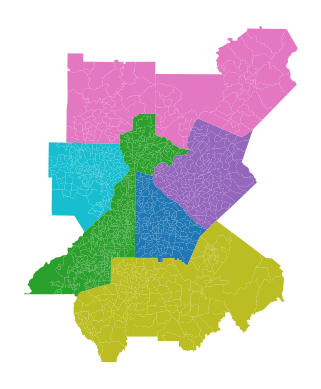

In [97]:
ax = geopandas.GeoDataFrame(metro_prec_data_rg_map).plot(legend=False, column='Region')
ax.set_axis_off()

# Import results

More will need to go here once we can actually use the SoS's json files

## Governor

In [98]:
prev = import_historical(2018, 'governor')
prev_table = display_single_results(prev)
prev_table

,Votes,Share
BRIAN KEMP (REP),1978408,50.221967
STACEY ABRAMS (DEM),1923685,48.832821
TED METZ (LIB),37235,0.945212


In [99]:
kemp2022 = 'Brian Kemp (I) (Rep)'
abrams2022 = 'Stacey Abrams (Dem)'
hazel2022 = 'Shane Hazel (Lib)'

winning_cand = prev_table.loc['BRIAN KEMP  (REP)'] # prev[kemp2022]
runner_up = prev_table.loc['STACEY ABRAMS  (DEM)'] # prev[abrams2022]
meta = {
    'Margin': winning_cand['Votes'] - runner_up['Votes'],
    'Margin (points)': winning_cand['Share'] - runner_up['Share'],
    'Swing required for Dem gain': 50 - runner_up['Share']
}
pd.Series(meta)


Margin                         54723.000000
Margin (points)                    1.389146
Swing required for Dem gain        1.167179
dtype: float64

In [100]:
curr = import_historical(2022, 'governor')
results_table = display_single_results(curr)

results_table.loc[kemp2022, 'Swing'] = results_table.loc[kemp2022, 'Share'] - prev_table.loc['BRIAN KEMP  (REP)', 'Share']
results_table.loc[abrams2022, 'Swing'] = results_table.loc[abrams2022, 'Share'] - prev_table.loc['STACEY ABRAMS  (DEM)', 'Share']
results_table.loc[hazel2022, 'Swing'] = results_table.loc[hazel2022, 'Share'] - prev_table.loc['TED METZ (LIB)', 'Share']

#jackson2026 = 'Rick Jackson (Rep)'
#bottoms2026 = 'Keisha Lance Bottoms (Dem)'
#results_table.loc[jackson2026, 'Swing'] = results_table.loc[jackson2026, 'Share'] - prev.loc[kemp2022, 'Share']
#results_table.loc[bottoms2026, 'Swing'] = results_table.loc[bottoms2026, 'Share'] - prev.loc[abrams2022, 'Share']

curr_dem = abrams2022
curr_rep = kemp2022
prev_dem = 'STACEY ABRAMS  (DEM)'
prev_rep = 'BRIAN KEMP  (REP)'

results_table

,Votes,Share,Swing
Brian Kemp (I) (Rep),2111572,53.411436,3.189470
Stacey Abrams (Dem),1813673,45.876191,-2.956630
Shane Hazel (Lib),28163,0.712373,-0.232839


In [101]:
votes = results_table['Votes'].tolist()
majority = votes[0] - votes[1]
majority

297899

In [102]:
import matplotlib.pyplot as plt

votes_in_doubt = 297899
total_projected = results_table['Votes'].sum() + votes_in_doubt
ranges = pd.DataFrame(results_table, columns=['Votes', 'Share'])
ranges['Min. Share'] = ranges['Votes'] / total_projected * 100
ranges['Max. Share'] = (ranges['Votes'] + votes_in_doubt) / total_projected * 100
ranges['Min. Del'] = ranges['Share'] - ranges['Min. Share']
ranges['Max. Del'] = ranges['Max. Share'] - ranges['Share']
ranges

#plt.barh(ranges.index, ranges['Share'], xerr=[ranges['Min. Del'], ranges['Max. Del']], )
#plt.show()

,Votes,Share,Min. Share,Max. Share,Min. Del,Max. Del
Brian Kemp (I) (Rep),2111572,53.411436,49.668772,56.676006,3.742664,3.264569
Stacey Abrams (Dem),1813673,45.876191,42.661539,49.668772,3.214652,3.792582
Shane Hazel (Lib),28163,0.712373,0.662455,7.669688,0.049918,6.957316


In [103]:
def cross_table(votes, votes_metro):
    def find_prg(i):
        (county, prec, _) = i
        prec = prec.upper()
        election = '*' if (county, prec, '*') in metro_prec_data.index else '2022'
        try:
            rg = metro_prec_data.loc[(county, prec, election), 'Reporting Group']
        except:
            return f'None, {county}'
        return f'{rg}, {county}'
    votes_metro['Reporting Group'] = votes_metro.index.map(find_prg)
    votes_metro = votes_metro.groupby(['Reporting Group', 'Vote Method']).sum()
    votes = pd.concat([votes, votes_metro])
    votes.index = votes.index.set_names(['County/Reporting Group', 'Vote Method'])
    # Setup
    cands = votes.columns
    votes = votes.groupby(level=['County/Reporting Group']).agg(sum)
    votes['Total Votes'] = votes.index.map(lambda i: votes.loc[i].sum())
    shares = pd.DataFrame(votes)
    # Region
    shares['Region'] = (
        metro_prec_data_rg_map['Region']
        .reindex(shares.index)
        .fillna(counties['Region'].reindex(shares.index))
    )
    shares = shares.groupby('Region').agg(sum)
    for cand in cands:
        shares[cand] = shares[cand] / shares['Total Votes'] * 100
    return cands, shares

prev_votes = pd.DataFrame(prev)
prev_votes_metro = import_historical(2018, 'governor', metro=True)
curr_votes = pd.DataFrame(curr)
curr_votes_metro = import_historical(2022, 'governor', metro=True)
(prev_cands, prev_shares) = cross_table(prev_votes, prev_votes_metro)
(curr_cands, curr_shares) = cross_table(curr_votes, curr_votes_metro)

index = pd.MultiIndex.from_tuples([y for x in [[(reg, 'Current'), (reg, 'Projection')] for reg in regions] for y in x], names=('Region', 'Model'))
curr_shares = pd.concat([curr_shares], axis=1, keys=['Share']).swaplevel(0, 1, 1)
curr_shares[(kemp2022, 'Swing')] = curr_shares[kemp2022, 'Share'] - prev_shares['BRIAN KEMP  (REP)']
curr_shares[(abrams2022, 'Swing')] = curr_shares[abrams2022, 'Share'] - prev_shares['STACEY ABRAMS  (DEM)']
curr_shares[(hazel2022, 'Swing')] = curr_shares[hazel2022, 'Share'] - prev_shares['TED METZ (LIB)']

curr_shares.sort_index(axis=1)\
    .drop(['Total Votes'], axis=1)

Brian Kemp (I) (Rep)           Shane Hazel (Lib)  \
                                   Share     Swing             Share   
Region                                                                 
DeKalb                         18.281924  2.279830          0.605575   
East                           69.935425  3.169854          0.772888   
Fulton                         30.524217  4.757219          0.626841   
Gwinnett                       44.435392  2.203950          0.786358   
Middle                         55.132689  3.093292          0.647975   
North                          82.235259  2.700357          0.874037   
North Metro Atlanta            74.342011  2.912765          0.908635   
South                          63.795842  3.067963          0.607669   
South Metro Atlanta            34.875438  0.930051          0.594650   
West                           71.159447  1.724333          0.774622   
West Metro Atlanta             47.306504  3.048269          0.847173   

                              Stacey Abrams (Dem)            
                        Swing               Share     Swing  
Region                                                       
DeKalb              -0.301546           81.112501 -1.978284  
East                -0.191871           29.291687 -2.977983  
Fulton              -0.366693           68.848941 -4.390526  
Gwinnett            -0.428393           54.778250 -1.775557  
Middle              -0.094823           44.219336 -2.998469  
North               -0.156918           16.890704 -2.543439  
North Metro Atlanta -0.579930           24.749355 -2.332835  
South               -0.055384           35.596489 -3.012579  
South Metro Atlanta -0.130549           64.529912 -0.799502  
West                -0.183363           28.065932 -1.540970  
West Metro Atlanta  -0.489800           51.846324 -2.558469

In [104]:
import model

swing_map = {
    'BRIAN KEMP  (REP)': kemp2022,
    'STACEY ABRAMS  (DEM)': abrams2022,
    'TED METZ (LIB)': hazel2022
}

vote_methods = curr_votes.index.get_level_values('Vote Method').unique()
index = pd.MultiIndex.from_tuples(utils.make_tuple_matrix(regions, 
                                                          vote_methods), 
                                                          names=['Region', 'Vote Method'])
proj_by_region = pd.DataFrame(index=index, columns=curr.columns)

for region in regions.unique():
    for method in vote_methods:
        df = prev.join(curr)
        df['Reported?'] = True
        df = df.reset_index(level='Vote Method')
        df = df[df['Vote Method'] == method]
        df['Region'] = counties['Region']
        df = df[df['Region'] == region]
        proj_by_region.loc[(region, method)] = model.project(df, prev_cands, curr_cands, swing_map)['Votes']

proj = proj_by_region.reset_index(level='Vote Method', drop=True).agg(sum)
proj

Brian Kemp (I) (Rep)    1297533.0
Stacey Abrams (Dem)      645182.0
Shane Hazel (Lib)         13783.0
dtype: float64

TODO for preceeding (statewide projection; fix metro results)

TODO for succeeding (swing histograms): Reporting by county (probably need to wait for full json)

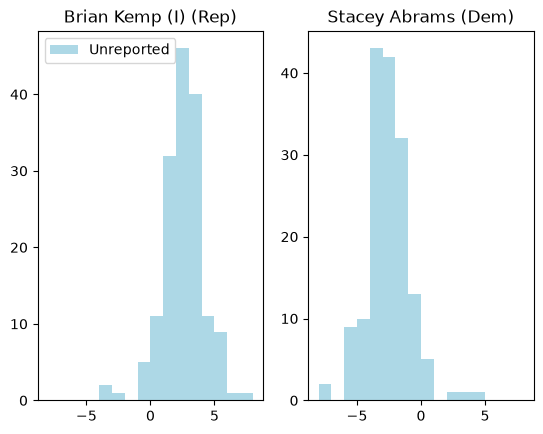

In [105]:
import numpy as np

def convt_to_shares(votes: pd.DataFrame, cands: list[str], group_by: str):
    shares = pd.DataFrame(votes)
    shares = shares.groupby(by=group_by).sum()
    shares['Total Votes'] = shares.index.map(lambda i: shares.loc[i].sum())
    for cand in cands:
        shares[cand] = shares[cand] / shares['Total Votes'] * 100
    return shares

def mk_swing(prev_shares: pd.DataFrame, curr_shares: pd.DataFrame):
    """Note: Does not count swings for third parties."""

    swings = pd.DataFrame(index=curr_shares.index)
    swings[curr_rep] = curr_shares[curr_rep] - prev_shares[prev_rep]
    swings[curr_dem] = curr_shares[curr_dem] - prev_shares[prev_dem]
    return swings

prev_shares_county = convt_to_shares(prev, prev_cands, 'County')
curr_shares_county = convt_to_shares(curr, curr_cands, 'County')

swings_county = mk_swing(prev_shares_county, curr_shares_county)

max_county_swing = swings_county.map(np.abs).max().max()
max_county_swing = int(np.ceil(max_county_swing))
range = (-max_county_swing, max_county_swing)
bins = max_county_swing * 2
fig, axes = plt.subplots(1, 2, squeeze=False)
for cand, ax in zip([kemp2022, abrams2022], axes[0]):
    ax.hist([swings_county[cand]], bins=bins, 
                    range=range, stacked=True, color=['lightblue'], 
                    label=['Unreported', 'Reported'])
    ax.set_title(cand)
l = axes[0][0].legend()

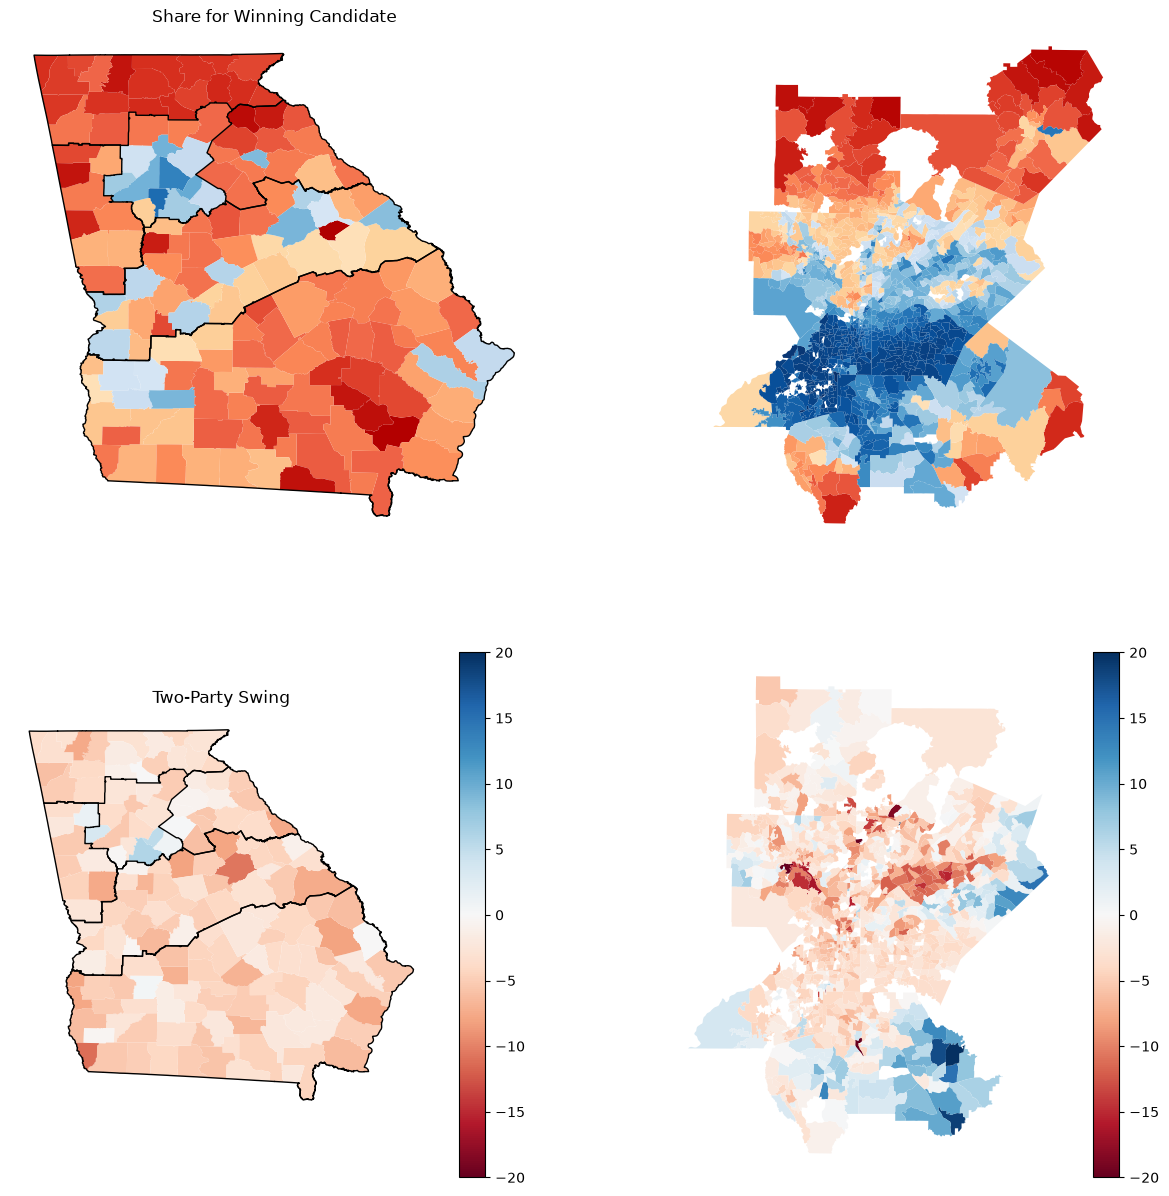

In [89]:
import geopandas
import matplotlib.colors as mcolors

prev_shares_metro = convt_to_shares(prev_votes_metro, prev_cands, 'Reporting Group')
curr_shares_metro = convt_to_shares(curr_votes_metro, curr_cands, 'Reporting Group')

swings_metro = mk_swing(prev_shares_metro, curr_shares_metro)

curr_shares_county['geometry'] = swings_county['geometry'] = counties['geometry']
curr_shares_county = geopandas.GeoDataFrame(curr_shares_county)
curr_shares_metro['geometry'] = swings_metro['geometry'] = metro_prec_data_rg_map['geometry']
curr_shares_metro = geopandas.GeoDataFrame(curr_shares_metro)
swings_county = geopandas.GeoDataFrame(swings_county)
swings_metro = geopandas.GeoDataFrame(swings_metro)
fig, axes = plt.subplots(2, 2, figsize=(15,15), squeeze=True)

share_nm_ax = axes[0][0]
swing_nm_ax = axes[1][0]
share_metro_ax = axes[0][1]
swing_metro_ax = axes[1][1]

curr_shares_county['Region'] = swings_county['Region'] = counties['Region']
curr_shares_county['Subregion'] = swings_county['Subregion'] = counties['Subregion']

missing_kwds={
    'color': 'lightgray',
    'edgecolor': 'red',
    'hatch': '///',
    'label': 'Missing values'
}

# Share map
def plot_shares(shares: pd.DataFrame, candidate: str, candidate_lgnd_label: str, ax: geopandas.Axis, cmap):
    shares[shares[candidate] > 50]\
        .plot(column=candidate, ax=ax, #legend=True, 
            cmap=cmap, missing_kwds=missing_kwds,
            legend_kwds={'label': candidate_lgnd_label, 'orientation': 'horizontal'},
            norm=mcolors.Normalize(40, 100))

# County (non-Metro share) (top-left)
plot_shares(curr_shares_county, kemp2022, 'Kemp', share_nm_ax, 'OrRd')
plot_shares(curr_shares_county, abrams2022, 'Abrams', share_nm_ax, 'Blues')
curr_shares_county.dissolve(by='Region').plot(ax=share_nm_ax, color='none')

# Metro share (top-right)
plot_shares(curr_shares_metro, kemp2022, 'Kemp', share_metro_ax, 'OrRd')
plot_shares(curr_shares_metro, abrams2022, 'Abrams', share_metro_ax, 'Blues')

# TPS Swing map
swings_county['TPS'] = swings_county[curr_dem] - swings_county[curr_rep] / 2
swings_metro['TPS'] = swings_metro[curr_dem] - swings_metro[curr_rep] / 2

swings_county.plot(column='TPS', ax=swing_nm_ax, legend=True, 
                   norm=mcolors.CenteredNorm(halfrange=20), cmap='RdBu')
swings_county.dissolve(by='Region').plot(ax=swing_nm_ax, color='none')

swings_metro.plot(column='TPS', ax=swing_metro_ax, legend=True, 
                   norm=mcolors.CenteredNorm(halfrange=20), cmap='RdBu')

share_nm_ax.set_title('Share for Winning Candidate')
share_nm_ax.set_axis_off()
swing_nm_ax.set_title('Two-Party Swing')
swing_nm_ax.set_axis_off()
share_metro_ax.set_axis_off()
swing_metro_ax.set_axis_off()

TODO for preceeding: 
* Missing metro precincts
* Scaling (colors; swing)
* Borders for metro maps
* Douglas County
* Data centers